In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('day.xls')

In [3]:
df = df.drop(['instant','dteday'],axis=1)

In [4]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
df['registered'].describe()

count     731.000000
mean     3656.172367
std      1560.256377
min        20.000000
25%      2497.000000
50%      3662.000000
75%      4776.500000
max      6946.000000
Name: registered, dtype: float64

In [6]:
df.shape

(731, 14)

In [7]:
df = df.drop_duplicates()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      731 non-null    int64  
 1   yr          731 non-null    int64  
 2   mnth        731 non-null    int64  
 3   holiday     731 non-null    int64  
 4   weekday     731 non-null    int64  
 5   workingday  731 non-null    int64  
 6   weathersit  731 non-null    int64  
 7   temp        731 non-null    float64
 8   atemp       731 non-null    float64
 9   hum         731 non-null    float64
 10  windspeed   731 non-null    float64
 11  casual      731 non-null    int64  
 12  registered  731 non-null    int64  
 13  cnt         731 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 80.1 KB


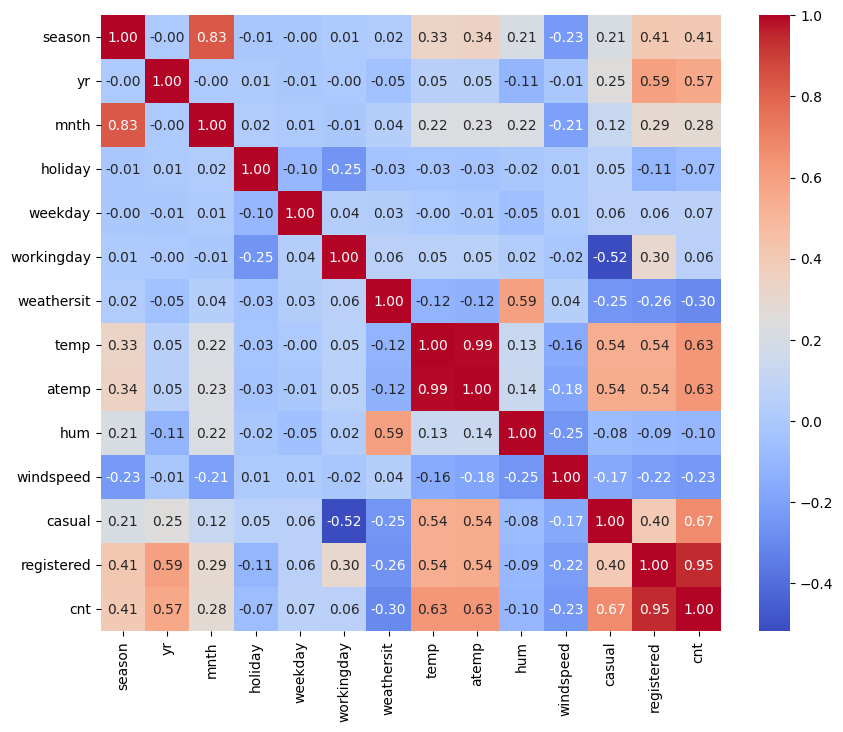

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, fmt='.2f',cmap='coolwarm')
plt.show()

In [10]:
X = df.drop(columns=['cnt', 'casual', 'registered'])
y = df['cnt']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [13]:
X.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test-----')

print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

result = []
result.append({
    'model':'linear',
    'train mse': mean_squared_error(y_train, y_pred_train),
    'train r2': r2_score(y_train, y_pred_train),
    'test mse':mean_squared_error(y_test, y_pred),
    'test r2' :r2_score(y_test, y_pred)
})

train
875.1110562766393
765819.3608176153
648.9110088886262
0.7910851850465888
test-----
831.2851545662686
691035.0082022651
617.3930656443374
0.8276670090367212


In [15]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_pred_train = knn.predict(X_train)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test-----')

print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
result.append({
    'model':'KNN',
    'train mse': mean_squared_error(y_train, y_pred_train),
    'train r2': r2_score(y_train, y_pred_train),
    'test mse':mean_squared_error(y_test, y_pred),
    'test r2' :r2_score(y_test, y_pred)
})

train
677.7212867424228
459306.14250380517
489.13299086757985
0.874701708160392
test-----
1031.3856140932098
1063756.2849584278
740.342403628118
0.7347163312032752


In [16]:
from xgboost import XGBRegressor

xg = XGBRegressor(n_estimators=101, max_depth=3)
xg.fit(X_train, y_train)

y_pred = xg.predict(X_test)
y_pred_train = xg.predict(X_train)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test-----')

print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

result.append({
    'model':'xg',
    'train mse': mean_squared_error(y_train, y_pred_train),
    'train r2': r2_score(y_train, y_pred_train),
    'test mse':mean_squared_error(y_test, y_pred),
    'test r2' :r2_score(y_test, y_pred)
})

train
254.9212646484375
64984.84765625
190.80540466308594
0.982272207736969
test-----
692.1527709960938
479075.46875
457.30133056640625
0.8805263042449951


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=101, max_depth=2)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test-----')

print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
result.append({
    'model':'random forest',
    'train mse': mean_squared_error(y_train, y_pred_train),
    'train r2': r2_score(y_train, y_pred_train),
    'test mse':mean_squared_error(y_test, y_pred),
    'test r2' :r2_score(y_test, y_pred)
})

train
965.797340737905
932764.5033764088
763.1091136574689
0.7455427042090647
test-----
1147.6026850470846
1316991.922727278
877.2481409815837
0.6715634455213594


In [18]:
from sklearn.svm import SVR

svc = SVR()
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
y_pred_train = svc.predict(X_train)

print('train')
print(root_mean_squared_error(y_train, y_pred_train))
print(mean_squared_error(y_train, y_pred_train))
print(mean_absolute_error(y_train, y_pred_train))
print(r2_score(y_train, y_pred_train))

print('test-----')

print(root_mean_squared_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

result.append({
    'model':'svr',
    'train mse': mean_squared_error(y_train, y_pred_train),
    'train r2': r2_score(y_train, y_pred_train),
    'test mse':mean_squared_error(y_test, y_pred),
    'test r2' :r2_score(y_test, y_pred)
})

train
1897.9380422167067
3602168.812093385
1534.699065559278
0.017331672046010826
test-----
2007.4938384481623
4030031.511407336
1700.0072426154488
-0.005024891349365346


In [19]:
results = pd.DataFrame(result)

In [20]:
results

,model,train mse,train r2,test mse,test r2
0,linear,7.658194e+05,0.791085,6.910350e+05,0.827667
1,KNN,4.593061e+05,0.874702,1.063756e+06,0.734716
2,xg,6.498485e+04,0.982272,4.790755e+05,0.880526
3,random forest,9.327645e+05,0.745543,1.316992e+06,0.671563
4,svr,3.602169e+06,0.017332,4.030032e+06,-0.005025
